# 06 -- Network Analysis

## Research Question
Which countries are structurally central in global trade -- not just big traders?

## Data
UN Comtrade + OECD BTiGE bilateral exports, 2016 and 2023, genuinely-complete 59-country network (see `docs/DATA_QUALITY.md` item 3). PUBLIC + DERIVED.

## Method
NetworkX directed graph; betweenness centrality, eigenvector centrality, and PageRank computed for both years, compared. See `python/networks/trade_network.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import sys, os
sys.path.insert(0, os.path.abspath('../python/visualisation'))
pd.set_option('display.max_columns', 20)

In [2]:
pagerank_change = pd.read_csv('../data/processed/trade_network_pagerank_change.csv')
print("Biggest network-importance gainers, 2016->2023 (PageRank):")
print(pagerank_change.sort_values('pagerank_change', ascending=False).head(6)[['Country','2016','2023','pagerank_change_pct']].round(4).to_string(index=False))
print("\nBiggest losers:")
print(pagerank_change.sort_values('pagerank_change').head(6)[['Country','2016','2023','pagerank_change_pct']].round(4).to_string(index=False))

Biggest network-importance gainers, 2016->2023 (PageRank):
      Country   2016   2023  pagerank_change_pct
        India 0.0342 0.0494              44.3777
  Netherlands 0.0311 0.0363              16.6967
      Belgium 0.0213 0.0244              14.7900
       Poland 0.0120 0.0148              23.3355
United States 0.1466 0.1490               1.6547
       Mexico 0.0314 0.0334               6.4869

Biggest losers:
             Country   2016   2023  pagerank_change_pct
      United Kingdom 0.0402 0.0312             -22.3834
Hong Kong SAR, China 0.0347 0.0265             -23.6177
               Japan 0.0332 0.0274             -17.5443
  Iran, Islamic Rep. 0.0072 0.0041             -42.8767
             Germany 0.0556 0.0534              -3.9497
              France 0.0358 0.0340              -4.9034


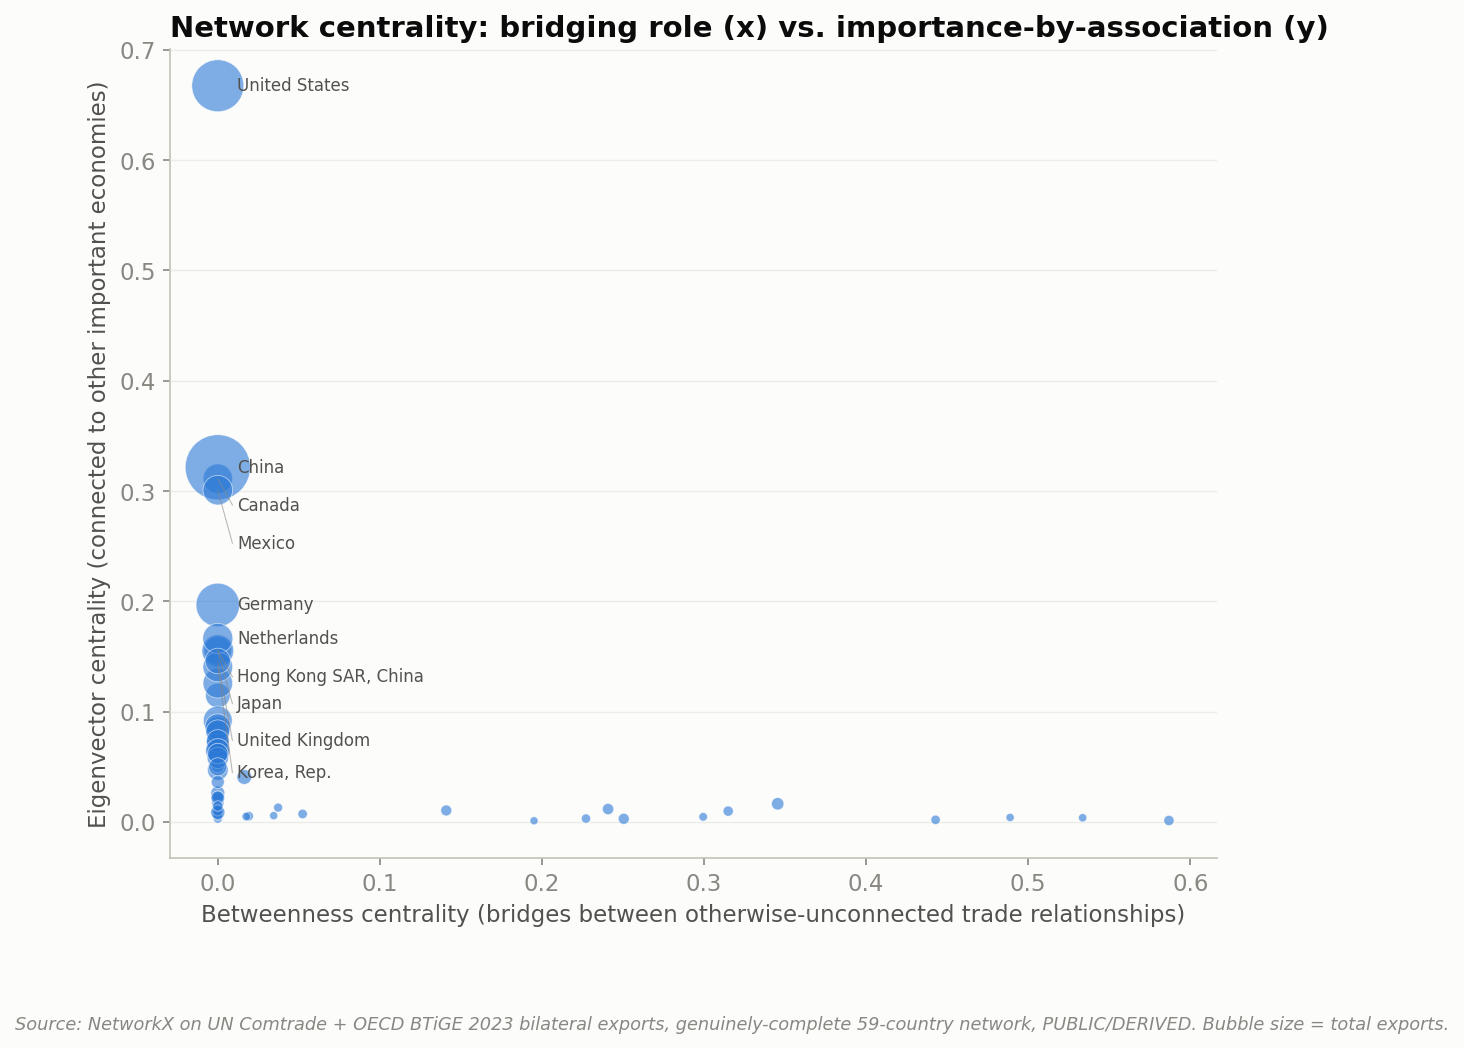

In [3]:
display(Image('../outputs/figures/11_network_centrality.png', width=750))

## Finding

India gained the most network importance of any economy 2016-\>2023 (+44% PageRank), followed by the Netherlands, Belgium, Poland, the United States, and Mexico. The UK, Hong Kong SAR, and Japan lost the most network importance over the same window (Iran lost the most of all, -43%), plausibly linked to Brexit, mainland China's relative port/manufacturing growth, and Japan's well-documented slow-growth trajectory respectively -- though this project's network data alone cannot establish causation for any of these, only the structural shift itself. This finding changed substantially once the United States, India, Belgium, and Ethiopia were correctly included in the network (see `docs/DATA_QUALITY.md` item 3): an earlier version of this analysis, built on the 55 countries UN Comtrade's free tier actually returns, had reported the UAE as the biggest gainer, a finding that does not survive completing the network.

## Limitation

Two time points only (2016, 2023). The United States, India, Belgium, and Ethiopia are absent from UN Comtrade's free tier specifically, but their centrality IS computed here, backfilled from OECD's Bilateral Trade in Goods database (see `docs/DATA_QUALITY.md` item 3); the residual caveat is that their edges come from a different source pipeline than the other 55 countries, documented in `docs/LIMITATIONS.md` item 17.

## Next Step

Notebook 07 combines everything into a formal risk index and produces a validated forecast for Malaysia.